In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [2]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/processed/nav_history_clean.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")
transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
print("AUM")
print(aum.columns)

print("\nSIP")
print(sip.columns)

print("\nCategory")
print(category.columns)

print("\nPortfolio")
print(portfolio.columns)

AUM
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

SIP
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

Category
Index(['month', 'category', 'net_inflow_crore'], dtype='str')

Portfolio
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [4]:
import pandas as pd
import plotly.express as px

# Convert date
nav["date"] = pd.to_datetime(nav["date"])

# Plot NAV trend
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.show()

# Save chart
fig.write_html("../charts/nav_trend.html")

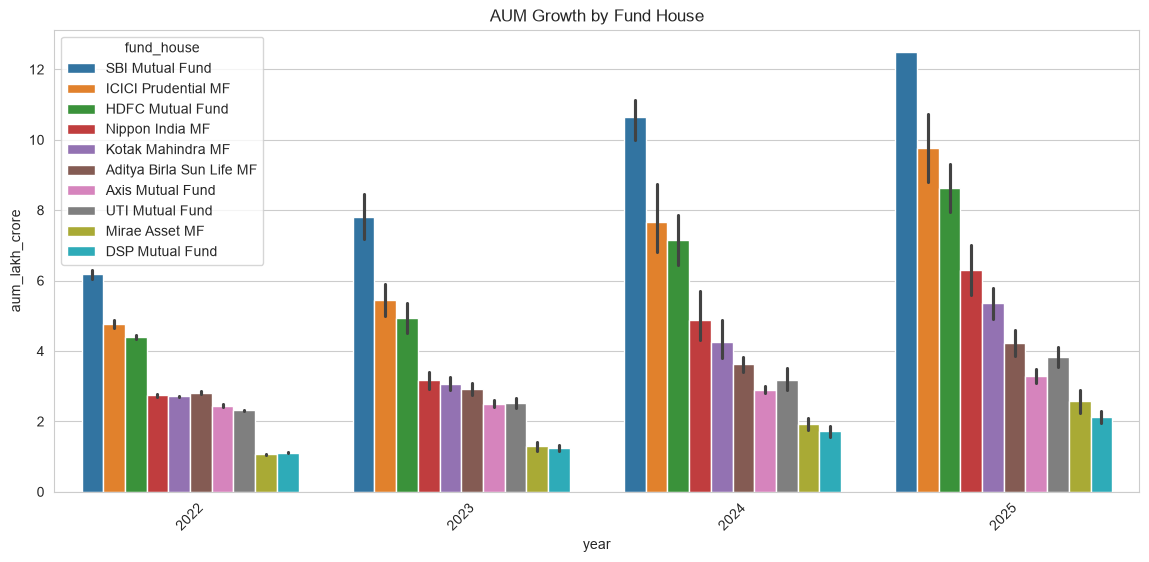

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert date
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.xticks(rotation=45)

plt.savefig("../charts/aum_growth.png")

plt.show()

In [6]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow"
)

fig.show()

fig.write_html("../charts/sip_trend.html")

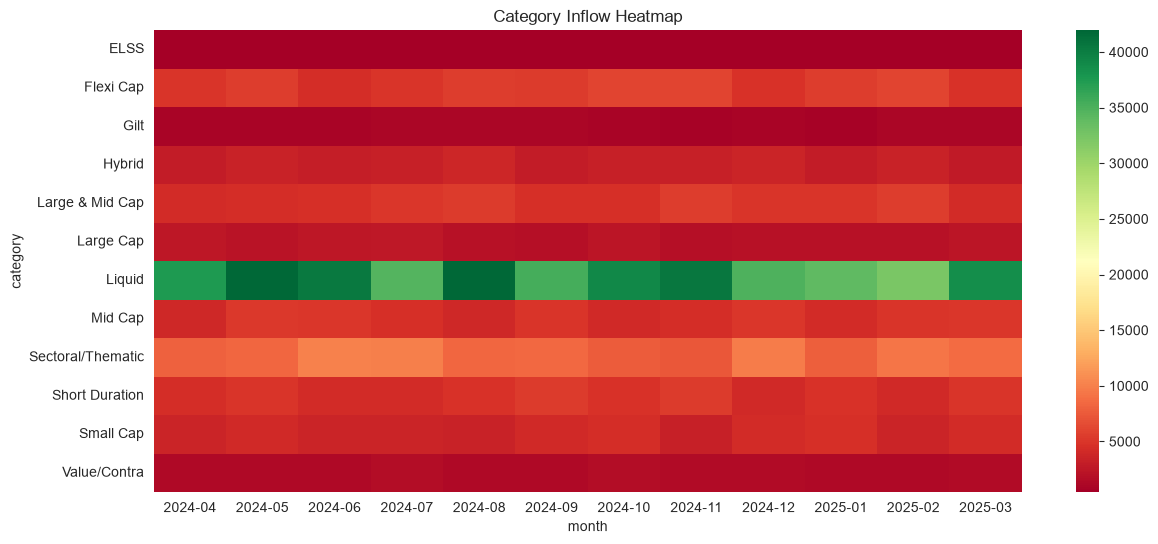

In [7]:
pivot = category.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="RdYlGn"
)

plt.title("Category Inflow Heatmap")

plt.savefig("../charts/category_heatmap.png")

plt.show()

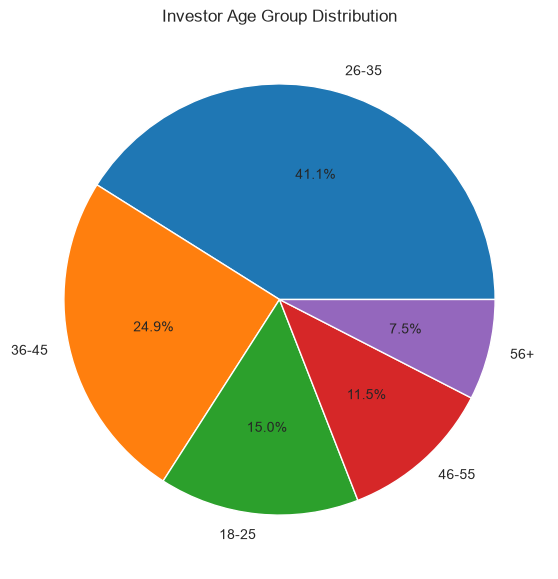

In [8]:
plt.figure(figsize=(7,7))

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.savefig("../charts/age_group_pie.png")

plt.show()

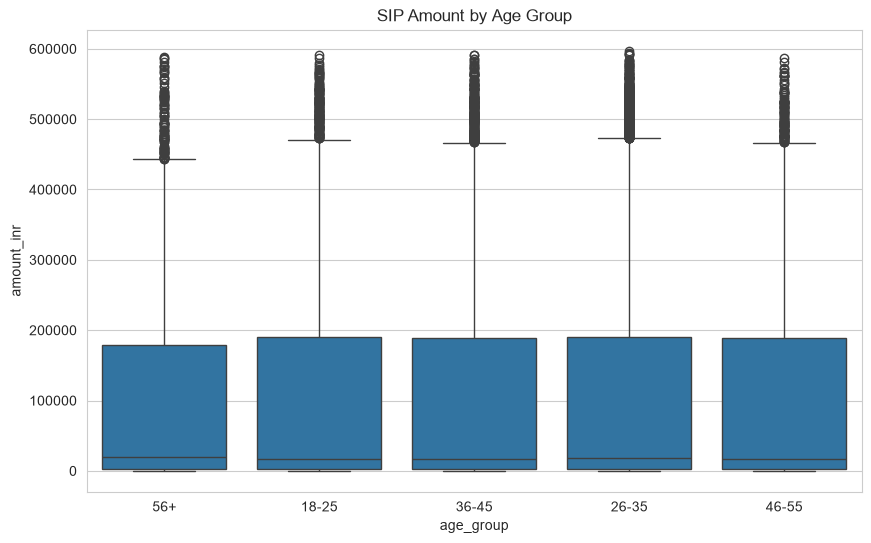

In [9]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")

plt.savefig("../charts/age_boxplot.png")

plt.show()

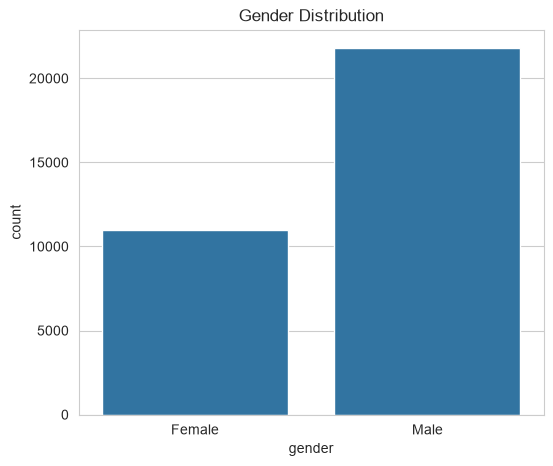

In [10]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=transactions,
    x="gender"
)

plt.title("Gender Distribution")

plt.savefig("../charts/gender.png")

plt.show()

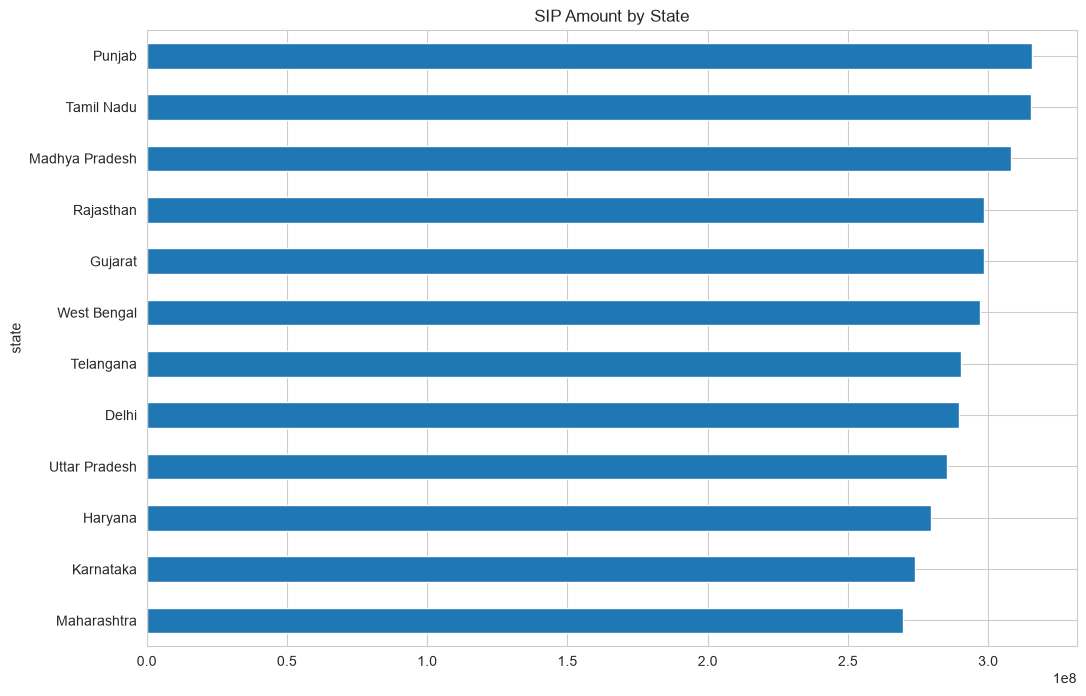

In [11]:
state = transactions.groupby("state")["amount_inr"].sum()

plt.figure(figsize=(12,8))

state.sort_values().plot(kind="barh")

plt.title("SIP Amount by State")

plt.savefig("../charts/state.png")

plt.show()

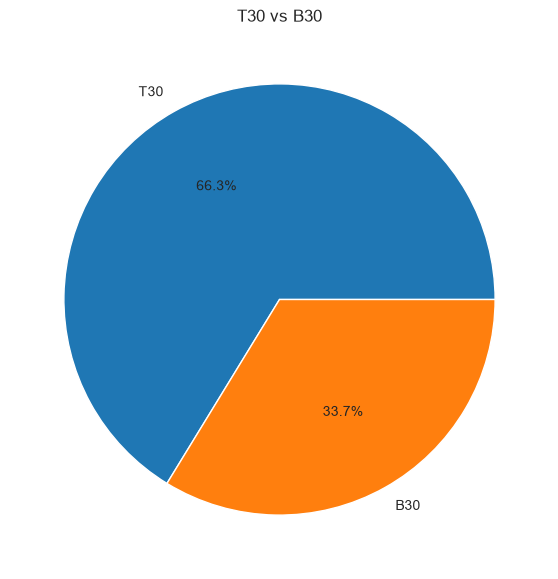

In [12]:
plt.figure(figsize=(7,7))

transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30")

plt.savefig("../charts/city_tier.png")

plt.show()

In [14]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))
plt.plot(folio["month"], folio["folio_count"])

plt.title("Industry Folio Growth")
plt.xlabel("Month")
plt.ylabel("Folio Count")

plt.savefig("../charts/folio_growth.png")
plt.show()

KeyError: 'folio_count'

<Figure size 1200x600 with 0 Axes>

In [15]:
print(folio.columns)

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


In [16]:
print(folio.head())

       month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0 2022-01-01               13.26                 9.28               1.86   
1 2022-04-01               13.91                 9.74               1.95   
2 2022-07-01               13.85                 9.69               1.94   
3 2022-10-01               14.12                 9.88               1.98   
4 2023-01-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


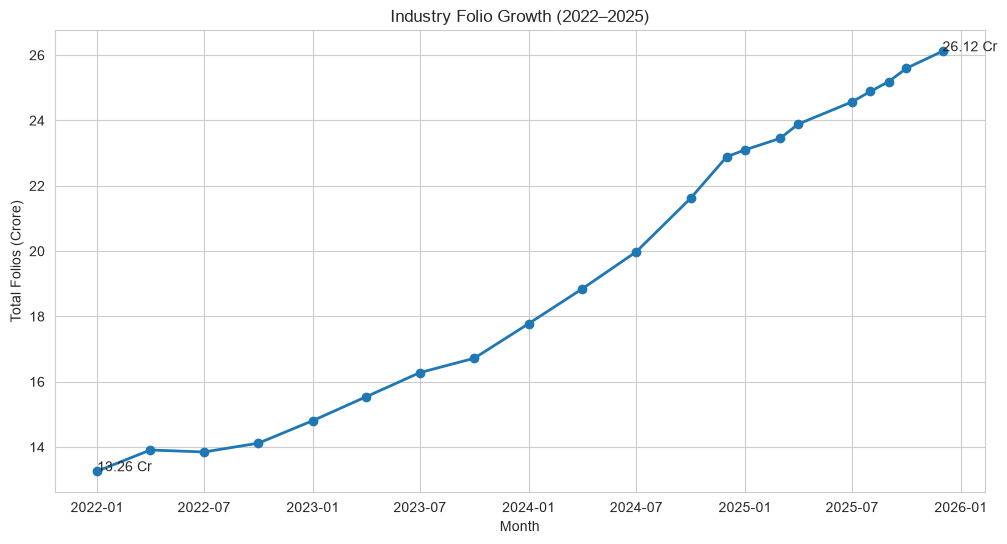

In [17]:
# Convert month to datetime
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Industry Folio Growth (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

# Mark first and last values
plt.annotate(
    "13.26 Cr",
    (folio["month"].iloc[0], folio["total_folios_crore"].iloc[0])
)

plt.annotate(
    "26.12 Cr",
    (folio["month"].iloc[-1], folio["total_folios_crore"].iloc[-1])
)

plt.grid(True)

plt.savefig("../charts/folio_growth.png")

plt.show()

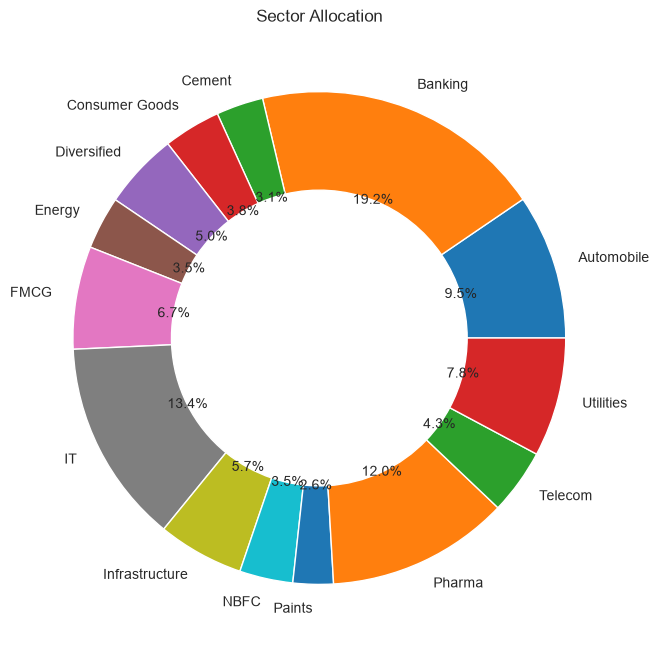

In [18]:
sector = portfolio.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation")

plt.savefig("../charts/sector_allocation.png")

plt.show()

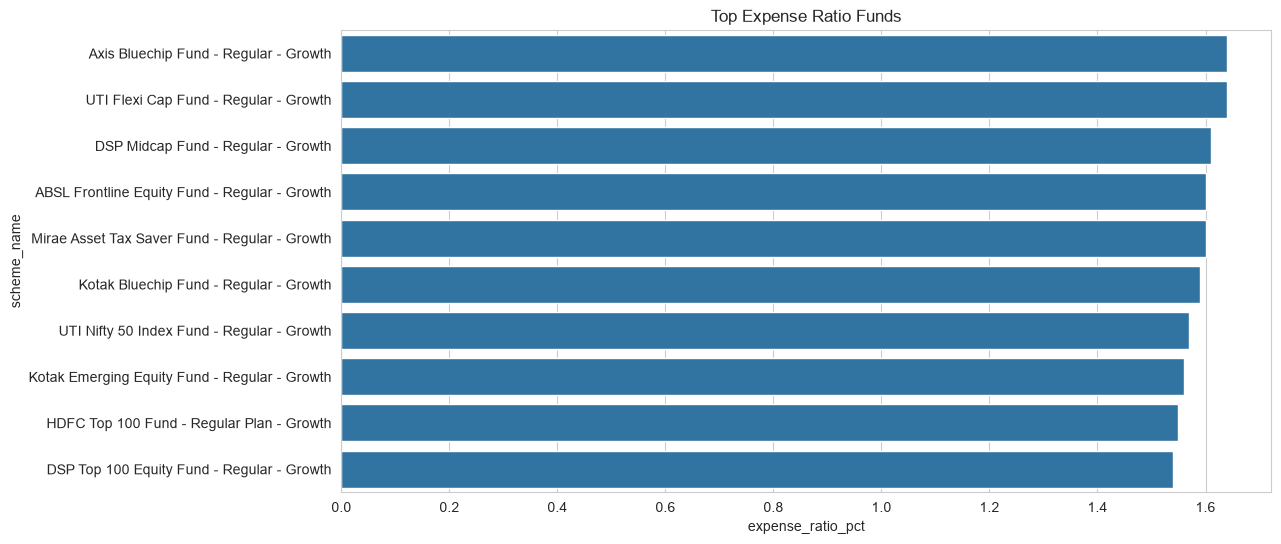

In [19]:
top = performance.sort_values(
    "expense_ratio_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top,
    x="expense_ratio_pct",
    y="scheme_name"
)

plt.title("Top Expense Ratio Funds")

plt.savefig("../charts/expense_ratio.png")

plt.show()